# 📊 Python Plotting Cheat Sheet: Matplotlib vs Pandas vs Seaborn

## 🔍 Overview

| Feature               | `Matplotlib (plt.plot)`        | `Pandas (df.plot)`               | `Seaborn (sns.lineplot)`              |
|-----------------------|-------------------------------|----------------------------------|----------------------------------------|
| **Style**             | Imperative (manual control)   | Declarative (auto-handled)       | Declarative + Styled                   |
| **Customization**     | 🔥 Max                        | 😐 Medium                        | 😊 Easy (fine-tune with `plt`)         |
| **Ease of Use**       | ❌ More verbose                | ✅ Very quick                     | ✅ Clean and styled                     |
| **Best For**          | Fine-tuned or complex plots   | Quick EDA                        | Publication-quality visuals            |
| **Data Input**        | Arrays or Series              | DataFrame / Series               | Tidy DataFrame (long-form)             |
| **Default Style**     | Basic                         | Basic                            | ⭐ Clean & consistent                   |
| **Learning Value**    | 🚀 High                        | 🧪 Medium                        | 🧪 Medium                              |
| **Category Ordering** | Manual                        | Based on DataFrame order         | May need `.reorder_categories()`       |

---

## 🧪 Example Setup

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

flights = sns.load_dataset('flights')
passengers_per_month = flights.groupby('month')['passengers'].sum()

C:\Users\jonma\AppData\Local\Temp\ipykernel_3948\445284215.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  passengers_per_month = flights.groupby('month')['passengers'].sum()


### 1. Matplotlib

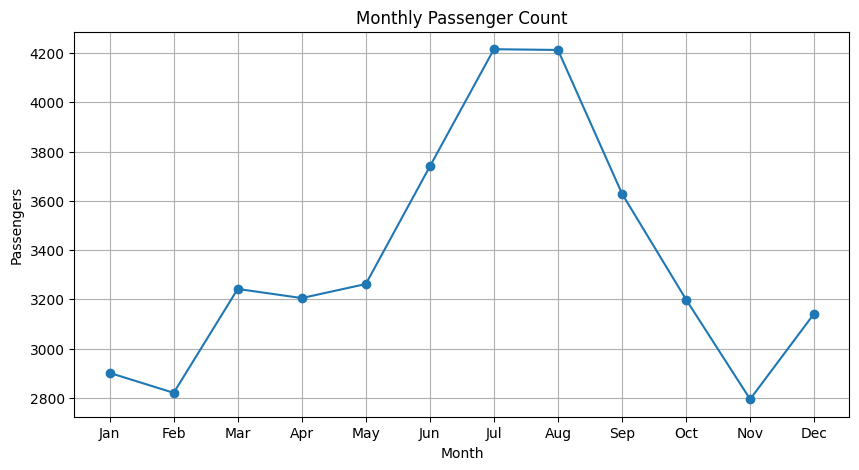

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(passengers_per_month.index, passengers_per_month.values, marker='o')
plt.title('Monthly Passenger Count')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()

### 2. Pandas Built-in

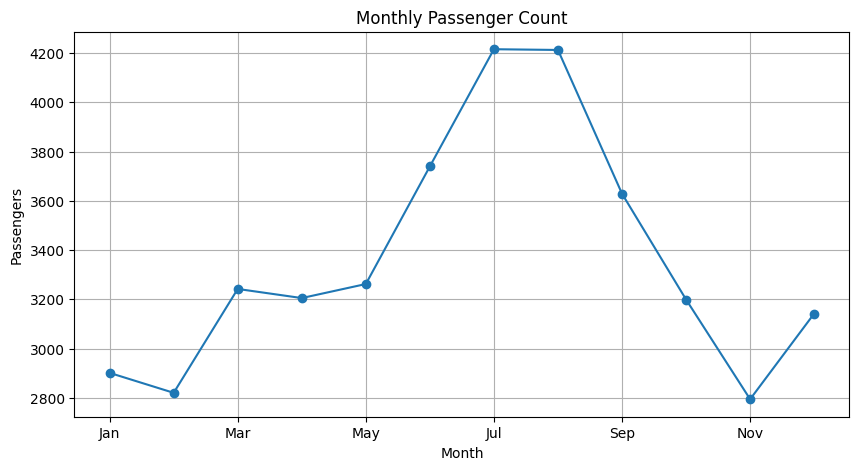

In [4]:
passengers_per_month.plot(marker='o', figsize=(10, 5))
plt.title('Monthly Passenger Count')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()

### 3. Seaborn

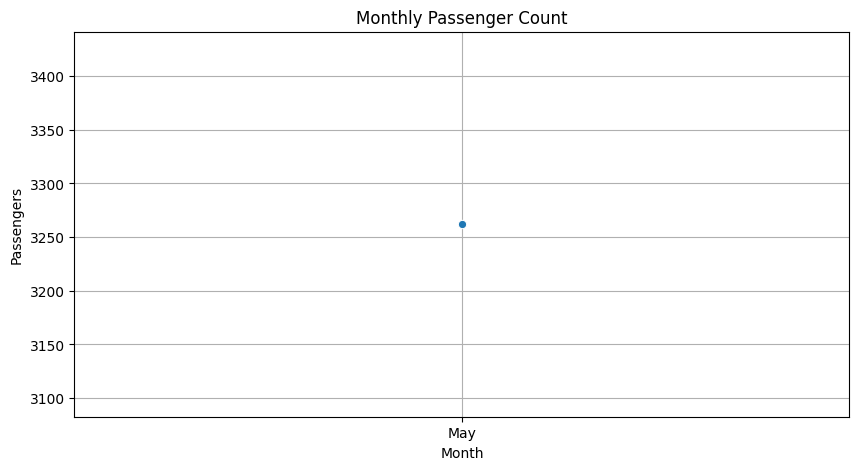

In [8]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

flights['month'] = pd.Categorical(flights['month'], categories=month_order, ordered=True)
monthwise = flights.groupby('month', observed=True)['passengers'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthwise, x='month', y='passengers', marker='o')
plt.title('Monthly Passenger Count')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()


### 🌟 Recommended Standard: Seaborn + Pandas + Matplotlib

C:\Users\jonma\AppData\Local\Temp\ipykernel_3948\2617155380.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_totals = flights.groupby('month')['passengers'].sum().reset_index()


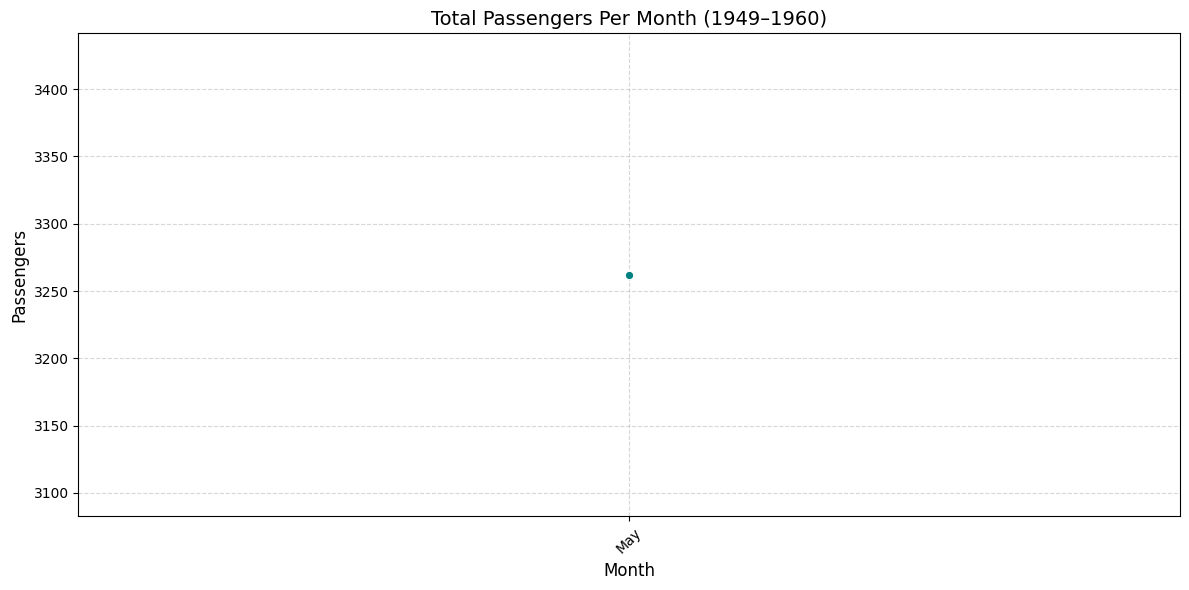

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
flights = sns.load_dataset('flights')

# Group and sort by month based on real month order (we'll fix that using a key sort)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Group by month and sum
monthly_totals = flights.groupby('month')['passengers'].sum().reset_index()

# Sort according to the month order
monthly_totals['month'] = pd.Categorical(monthly_totals['month'], categories=month_order, ordered=True)
monthly_totals = monthly_totals.sort_values('month')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_totals, x='month', y='passengers', marker='o', color='teal')

plt.title("Total Passengers Per Month (1949–1960)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Passengers", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 🧠 Pro Tips
✅ Fix month order to avoid alphabetical plotting.

✅ Use plt.tight_layout() to prevent label overlap.

✅ Combine Seaborn for looks, Matplotlib for fine-tuning.

✅ For grouped or multi-line plots, Seaborn handles legends/colors beautifully.